In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv("data/cfpb-complaints-2026-02-05_20_10.csv",engine="python",
    on_bad_lines="skip")
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761


In [6]:
print(f"\nShape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Shape: (1400010, 18)
Memory usage: 2777.98 MB


In [7]:
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

   1. Date received
   2. Product
   3. Sub-product
   4. Issue
   5. Sub-issue
   6. Consumer complaint narrative
   7. Company public response
   8. Company
   9. State
  10. ZIP code
  11. Tags
  12. Consumer consent provided?
  13. Submitted via
  14. Date sent to company
  15. Company response to consumer
  16. Timely response?
  17. Consumer disputed?
  18. Complaint ID


In [8]:
critical_cols = [
        'Consumer complaint narrative',
        'Product',
        'Issue',
        'Date received',
        'Company response to consumer'
    ]
    
for col in critical_cols:
        if col in df.columns:
            print(f"'{col}' found")
        else:
            print(f"'{col}' MISSING!")

'Consumer complaint narrative' found
'Product' found
'Issue' found
'Date received' found
'Company response to consumer' found


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
    
missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing': missing.values,
        'Percent': missing_pct.values
    }).sort_values('Percent', ascending=False)

In [10]:
print(missing_df.head(10).to_string(index=False))

                      Column  Missing    Percent
          Consumer disputed?  1400010 100.000000
                        Tags  1294267  92.446983
     Company public response   606281  43.305476
                   Sub-issue    71949   5.139178
                       State     4443   0.317355
Company response to consumer        4   0.000286
                 Sub-product        2   0.000143
               Date received        0   0.000000
                     Product        0   0.000000
Consumer complaint narrative        0   0.000000


In [11]:
narrative_col = 'Consumer complaint narrative'
sample = df[df[narrative_col].notna()][narrative_col].iloc[0]
print(f"\n  Sample narrative (first 200 chars):")
print(f"  '{sample[:200]}...'")


  Sample narrative (first 200 chars):
  'I am writing to have the following information removed from my credit file, the items that I need deleted are going to be attached in a word document. I am a victim of identity theft. I have multiple ...'


In [12]:
if 'Date received' in df.columns:
        df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
        print(f"\n  Earliest complaint: {df['Date received'].min()}")
        print(f"  Latest complaint:   {df['Date received'].max()}")
        print(f"  Date range:         {(df['Date received'].max() - df['Date received'].min()).days} days")

C:\Users\shubh\AppData\Local\Temp\ipykernel_31692\341639383.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')



  Earliest complaint: 2022-02-04 00:00:00
  Latest complaint:   2026-01-15 00:00:00
  Date range:         1441 days


In [13]:
if 'Product' in df.columns:
        print("\n  Top 10 products by complaint count:")
        product_counts = df['Product'].value_counts().head(10)
        for product, count in product_counts.items():
            pct = (count / len(df)) * 100
            print(f"    {product:40s}: {count:7,} ({pct:5.2f}%)")


  Top 10 products by complaint count:
    Credit reporting or other personal consumer reports: 823,665 (58.83%)
    Credit reporting, credit repair services, or other personal consumer reports: 220,199 (15.73%)
    Debt collection                         : 112,085 ( 8.01%)
    Checking or savings account             :  62,640 ( 4.47%)
    Money transfer, virtual currency, or money service:  45,043 ( 3.22%)
    Credit card                             :  44,750 ( 3.20%)
    Mortgage                                :  25,056 ( 1.79%)
    Credit card or prepaid card             :  20,743 ( 1.48%)
    Vehicle loan or lease                   :  15,250 ( 1.09%)
    Student loan                            :  14,370 ( 1.03%)


## Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS

 Generating time series analysis...
Saved: eda_overview.png


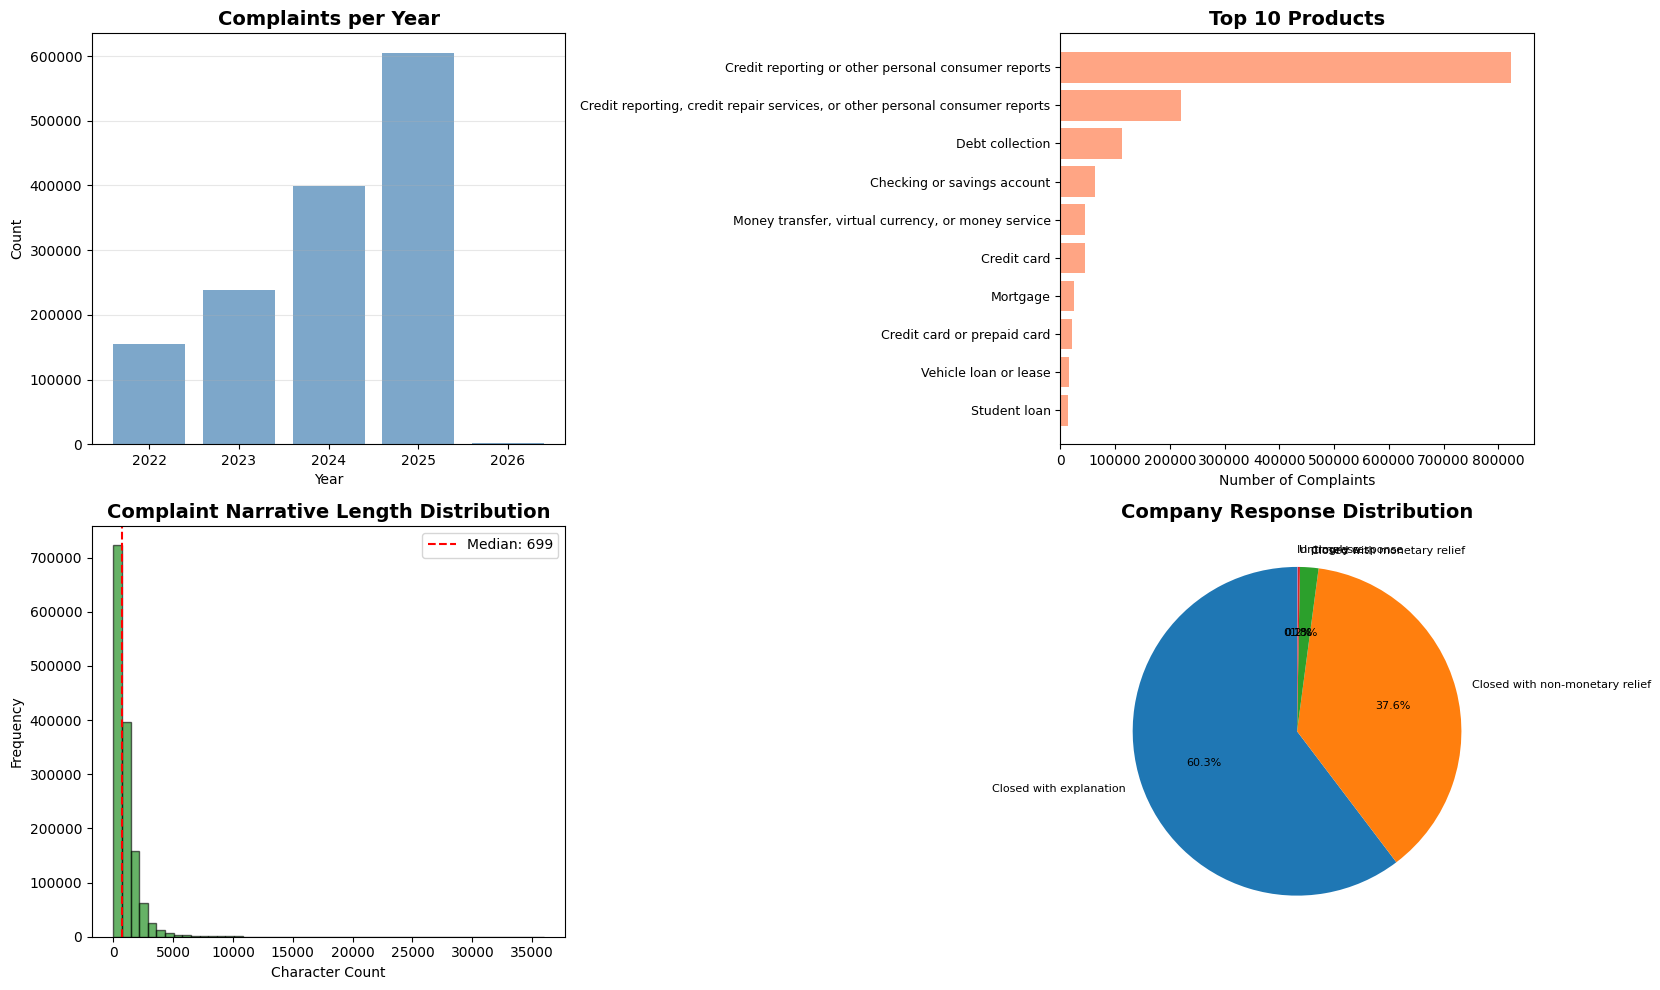


Text statistics:
  Min length     :       4.00
  Max length     :   35984.00
  Mean length    :    1009.88
  Median length  :     699.00
  Std dev        :    1201.41

 Top issues:
   1. Incorrect information on your report              : 490,637
   2. Improper use of your report                       : 306,642
   3. Problem with a company's investigation into an existing problem: 175,930
   4. Problem with a credit reporting company's investigation into an existing problem: 67,441
   5. Attempts to collect debt not owed                 : 51,895
   6. Managing an account                               : 33,907
   7. Written notification about debt                   : 27,186
   8. Other transaction problem                         : 25,063
   9. Problem with a purchase shown on your statement   : 16,477
  10. Trouble during payment process                    : 13,357


In [14]:
def perform_eda(df):
    """
    Comprehensive EDA with visualizations
    
    Parameters:
    -----------
    df : pandas.DataFrame
        CFPB complaints dataframe
    """
    
    print("=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)
    
    # ─── EDA 1: Complaints Over Time ───
    print("\n Generating time series analysis...")
    
    df['Year'] = df['Date received'].dt.year
    df['Month'] = df['Date received'].dt.to_period('M')
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Complaints per year
    yearly = df['Year'].value_counts().sort_index()
    axes[0, 0].bar(yearly.index, yearly.values, color='steelblue', alpha=0.7)
    axes[0, 0].set_title('Complaints per Year', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Year')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Complaints per product
    top_products = df['Product'].value_counts().head(10)
    axes[0, 1].barh(range(len(top_products)), top_products.values, color='coral', alpha=0.7)
    axes[0, 1].set_yticks(range(len(top_products)))
    axes[0, 1].set_yticklabels(top_products.index, fontsize=9)
    axes[0, 1].set_title('Top 10 Products', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Complaints')
    axes[0, 1].invert_yaxis()
    
    # Narrative length distribution
    df['narrative_length'] = df['Consumer complaint narrative'].fillna('').str.len()
    narrative_lengths = df[df['narrative_length'] > 0]['narrative_length']
    
    axes[1, 0].hist(narrative_lengths, bins=50, color='green', alpha=0.6, edgecolor='black')
    axes[1, 0].set_title('Complaint Narrative Length Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Character Count')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(narrative_lengths.median(), color='red', linestyle='--', 
                       label=f'Median: {narrative_lengths.median():.0f}')
    axes[1, 0].legend()
    
    # Company response distribution
    if 'Company response to consumer' in df.columns:
        response_counts = df['Company response to consumer'].value_counts().head(8)
        axes[1, 1].pie(response_counts.values, labels=response_counts.index, autopct='%1.1f%%',
                       startangle=90, textprops={'fontsize': 8})
        axes[1, 1].set_title('Company Response Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('eda_overview.png', dpi=300, bbox_inches='tight')
    print("Saved: eda_overview.png")
    plt.show()
    
    # ─── EDA 2: Text Statistics ───
    print("\nText statistics:")
    
    text_stats = {
        'Min length': narrative_lengths.min(),
        'Max length': narrative_lengths.max(),
        'Mean length': narrative_lengths.mean(),
        'Median length': narrative_lengths.median(),
        'Std dev': narrative_lengths.std()
    }
    
    for stat, value in text_stats.items():
        print(f"  {stat:15s}: {value:10.2f}")
    
    # ─── EDA 3: Issue Analysis ───
    print("\n Top issues:")
    
    if 'Issue' in df.columns:
        top_issues = df['Issue'].value_counts().head(10)
        for i, (issue, count) in enumerate(top_issues.items(), 1):
            print(f"  {i:2d}. {issue:50s}: {count:6,}")
    
    return df


# ─── USAGE ───
df = perform_eda(df)